In [27]:
import os
import json
import time
import re
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from transformers import pipeline
import torch

In [13]:
BASE_DIR = Path("results/llm_reference")
OUTPUT_PATH = BASE_DIR / "llm_span_annotations_100_tp_gemini_perturbation_eval.csv"

MODEL_NAME = "timonziegenbein/appropriateness-classifier-binary"
MAX_LENGTH = 512
BATCH_SIZE = 16
DEVICE = torch.device("mps" if torch.mps.is_available() else "cpu")

pipe = pipeline(
    "text-classification",
    model=MODEL_NAME,
    device=DEVICE,
    top_k=None,
    truncation=True,
    max_length=MAX_LENGTH
)

tokenizer = pipe.tokenizer
model = pipe.model
model.eval()

MASK_TOKEN = tokenizer.mask_token if tokenizer.mask_token is not None else "[MASK]"

print("Mask token:", MASK_TOKEN)
print("Model labels:", model.config.id2label)
pipe

Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

Mask token: [MASK]
Model labels: {0: 'LABEL_0', 1: 'LABEL_1'}


TextClassificationPipeline: {'model': 'DebertaV2ForSequenceClassification', 'dtype': 'float32', 'device': 'mps', 'input_modalities': 'text'}

In [9]:
llm_ref = pd.read_csv(BASE_DIR / "llm_span_annotations_100_tp_gemini_batched.csv")

print("Total rows:", len(llm_ref))
print("Valid counts:")
print(llm_ref["llm_valid"].value_counts(dropna=False))

display(llm_ref.head(10))

Total rows: 100
Valid counts:
llm_valid
True    100
Name: count, dtype: int64


,global_row_id,post_id,split,issue,argument,Inappropriateness,p_inappropriate,llm_span_text,llm_char_start_original,llm_char_end_original,llm_char_start,llm_char_end,llm_confidence,llm_valid,llm_fixed_offsets,llm_error,model_name
0,8,11,train,India has the potential to lead the world:,"stupid india they actually really suck. so, BO...",1,0.997709,stupid india they actually really suck,0,38,0,38,0.95,True,False,NaN,gemini-3-flash-preview
1,17,24,train,Evolution vs creation:,"Believing ""Evolution"" as in Darwinism and the ...",1,0.998401,is like believing the puzzle can be solved by ...,52,163,52,163,0.80,True,False,NaN,gemini-3-flash-preview
2,49,69,train,Pro choice vs pro life:,There are tons of ways to not get pregnant. Th...,1,0.998481,It's the woman's fault,205,227,206,228,0.90,True,True,NaN,gemini-3-flash-preview
3,53,74,train,Gay marriage right or wrong:,If you do not like gay marriage and thing it i...,1,0.998355,keep them to yourself,286,307,286,307,0.90,True,False,NaN,gemini-3-flash-preview
4,88,123,train,Cmv: the minute you intentionally put a person...,"These days, we grant more rights to convict's ...",1,0.997135,we would all be better off if you were dead,474,517,474,517,0.90,True,False,NaN,gemini-3-flash-preview
5,95,132,train,The only one playing god is the man with the g...,I hear all too often that science is 'playing ...,1,0.997560,"If god did not intend us to do so, he is nears...",577,672,576,671,1.00,True,True,NaN,gemini-3-flash-preview
6,96,133,train,0% gun tolerance on the streets in the us st...,Unless every single gun that is issued legally...,1,0.994609,It's bull sh*t.,384,399,403,418,1.00,True,True,NaN,gemini-3-flash-preview
7,135,193,train,Is porn wrong:,I note that whenever someone starts in on the ...,1,0.998351,"""Feminist"" bullsh*t",271,290,271,290,0.95,True,False,NaN,gemini-3-flash-preview
8,145,209,train,Gay marriage right or wrong:,If being homosexual was natural then\r\n1. The...,1,0.998443,piss ant liberal,454,470,455,471,0.95,True,True,NaN,gemini-3-flash-preview
9,157,224,train,Pro choice vs pro life:,for everyone who is talking about RAPE in this...,1,0.998182,you need to see a Physiatrist!!!!,300,333,300,333,0.90,True,False,NaN,gemini-3-flash-preview


In [10]:
# Normalize boolean column robustly.
llm_ref["llm_valid_bool"] = (
    llm_ref["llm_valid"]
    .astype(str)
    .str.lower()
    .isin(["true", "1", "yes"])
)

valid_llm = llm_ref[llm_ref["llm_valid_bool"]].copy()

print("Valid LLM spans:", len(valid_llm))
print("Invalid LLM spans:", len(llm_ref) - len(valid_llm))

valid_llm[[
    "global_row_id",
    "argument",
    "llm_span_text",
    "llm_char_start",
    "llm_char_end",
    "llm_confidence"
]].head()

Valid LLM spans: 100
Invalid LLM spans: 0


,global_row_id,argument,llm_span_text,llm_char_start,llm_char_end,llm_confidence
0,8,"stupid india they actually really suck. so, BO...",stupid india they actually really suck,0,38,0.95
1,17,"Believing ""Evolution"" as in Darwinism and the ...",is like believing the puzzle can be solved by ...,52,163,0.80
2,49,There are tons of ways to not get pregnant. Th...,It's the woman's fault,206,228,0.90
3,53,If you do not like gay marriage and thing it i...,keep them to yourself,286,307,0.90
4,88,"These days, we grant more rights to convict's ...",we would all be better off if you were dead,474,517,0.90


In [11]:
def extract_p_inappropriate(prediction):
    """
    Extract the probability of the inappropriate class from a pipeline prediction.

    The function is intentionally robust because Hugging Face models may expose
    labels as 'LABEL_0'/'LABEL_1' or as textual labels such as 'appropriate' and
    'inappropriate'.
    """
    label_scores = {
        item["label"].lower(): float(item["score"])
        for item in prediction
    }

    # Preferred explicit label names.
    for key in label_scores:
        if "inappropriate" in key:
            return label_scores[key]

    # Common binary fallback: LABEL_1 is often the positive class.
    if "label_1" in label_scores:
        return label_scores["label_1"]

    # Fallback to the second item if available.
    if len(prediction) >= 2:
        return float(prediction[1]["score"])

    raise ValueError(f"Could not extract inappropriate score from: {prediction}")

In [14]:
def predict_p_inappropriate_batch(texts, batch_size=16):
    """
    Predict inappropriate probabilities for a list of texts using the classifier.

    Empty texts are replaced by a single whitespace-safe placeholder to avoid
    tokenizer errors. The returned list has the same length as the input list.
    """
    cleaned_texts = []

    for text in texts:
        text = "" if pd.isna(text) else str(text)
        text = text.strip()

        if text == "":
            text = " "

        cleaned_texts.append(text)

    outputs = pipe(cleaned_texts, batch_size=batch_size)

    return [extract_p_inappropriate(pred) for pred in outputs]

In [15]:
test_texts = [
    "You are stupid and your argument is worthless.",
    "I disagree because the policy may have unintended consequences."
]

predict_p_inappropriate_batch(test_texts, batch_size=2)

[0.9983471632003784, 0.021384069696068764]

In [19]:
def normalize_whitespace(text):
    """
    Normalize repeated whitespace while keeping the text otherwise unchanged.
    """
    return re.sub(r"\s+", " ", str(text)).strip()

def validate_span_slice(argument, start, end, expected_span=None):
    """
    Validate whether character offsets define a usable span.

    If expected_span is provided, the function checks whether the slice matches
    the expected span exactly. This is useful for debugging LLM offset errors.
    """
    argument = str(argument)

    if pd.isna(start) or pd.isna(end):
        return False, None, "missing_offsets"

    start = int(start)
    end = int(end)

    if start < 0 or end <= start or end > len(argument):
        return False, None, "invalid_range"

    extracted = argument[start:end]

    if expected_span is not None and not pd.isna(expected_span):
        expected_span = str(expected_span)

        if extracted != expected_span:
            return False, extracted, "slice_mismatch"

    return True, extracted, "ok"

def mask_char_span(argument, start, end, mask_token="[MASK]"):
    """
    Replace the character span [start, end) with one mask token.

    This evaluates how much the classifier's inappropriate probability drops
    when the LLM-selected span is hidden but the surrounding context remains.
    """
    argument = str(argument)
    start = int(start)
    end = int(end)

    perturbed = argument[:start] + f" {mask_token} " + argument[end:]

    return normalize_whitespace(perturbed)

def delete_char_span(argument, start, end):
    """
    Delete the character span [start, end) from the argument.

    This evaluates how much the classifier's inappropriate probability drops
    when the LLM-selected span is completely removed.
    """
    argument = str(argument)
    start = int(start)
    end = int(end)

    perturbed = argument[:start] + " " + argument[end:]

    return normalize_whitespace(perturbed)

def get_span_only_text(argument, start, end):
    """
    Extract only the LLM-selected span from the original argument.

    The resulting text is later passed through the classifier to estimate how
    inappropriate the span is in isolation.
    """
    argument = str(argument)
    start = int(start)
    end = int(end)

    return argument[start:end].strip()

In [20]:
eval_df = valid_llm.copy()

# Ensure numeric offsets.
eval_df["llm_char_start"] = pd.to_numeric(eval_df["llm_char_start"], errors="coerce")
eval_df["llm_char_end"] = pd.to_numeric(eval_df["llm_char_end"], errors="coerce")

rows = []

for _, row in eval_df.iterrows():
    argument = str(row["argument"])
    start = row["llm_char_start"]
    end = row["llm_char_end"]
    expected_span = row.get("llm_span_text", None)

    is_valid_slice, extracted_span, slice_status = validate_span_slice(
        argument=argument,
        start=start,
        end=end,
        expected_span=expected_span
    )

    if not is_valid_slice:
        masked_text = None
        deleted_text = None
        span_only_text = None
    else:
        masked_text = mask_char_span(
            argument=argument,
            start=start,
            end=end,
            mask_token=MASK_TOKEN
        )

        deleted_text = delete_char_span(
            argument=argument,
            start=start,
            end=end
        )

        span_only_text = get_span_only_text(
            argument=argument,
            start=start,
            end=end
        )

    rows.append({
        "global_row_id": row["global_row_id"],
        "span_slice_valid": is_valid_slice,
        "span_slice_status": slice_status,
        "span_text_from_offsets": extracted_span,
        "masked_text": masked_text,
        "deleted_text": deleted_text,
        "span_only_text": span_only_text
    })

perturb_df = pd.DataFrame(rows)

eval_df = eval_df.merge(
    perturb_df,
    on="global_row_id",
    how="left"
)

print(eval_df["span_slice_status"].value_counts(dropna=False))

eval_df[[
    "global_row_id",
    "argument",
    "llm_span_text",
    "span_text_from_offsets",
    "masked_text",
    "deleted_text",
    "span_only_text",
    "span_slice_status"
]].head()

span_slice_status
ok    100
Name: count, dtype: int64


,global_row_id,argument,llm_span_text,span_text_from_offsets,masked_text,deleted_text,span_only_text,span_slice_status
0,8,"stupid india they actually really suck. so, BO...",stupid india they actually really suck,stupid india they actually really suck,"[MASK] . so, BOO INDIA BOO!",". so, BOO INDIA BOO!",stupid india they actually really suck,ok
1,17,"Believing ""Evolution"" as in Darwinism and the ...",is like believing the puzzle can be solved by ...,is like believing the puzzle can be solved by ...,"Believing ""Evolution"" as in Darwinism and the ...","Believing ""Evolution"" as in Darwinism and the ...",is like believing the puzzle can be solved by ...,ok
2,49,There are tons of ways to not get pregnant. Th...,It's the woman's fault,It's the woman's fault,There are tons of ways to not get pregnant. Th...,There are tons of ways to not get pregnant. Th...,It's the woman's fault,ok
3,53,If you do not like gay marriage and thing it i...,keep them to yourself,keep them to yourself,If you do not like gay marriage and thing it i...,If you do not like gay marriage and thing it i...,keep them to yourself,ok
4,88,"These days, we grant more rights to convict's ...",we would all be better off if you were dead,we would all be better off if you were dead,"These days, we grant more rights to convict's ...","These days, we grant more rights to convict's ...",we would all be better off if you were dead,ok


In [22]:
scorable = eval_df[eval_df["span_slice_valid"]].copy()
print("Scorable rows:", len(scorable))

original_texts = scorable["argument"].astype(str).tolist()
masked_texts = scorable["masked_text"].astype(str).tolist()
deleted_texts = scorable["deleted_text"].astype(str).tolist()
span_only_texts = scorable["span_only_text"].astype(str).tolist()

p_original_pred = predict_p_inappropriate_batch(
    original_texts,
    batch_size=BATCH_SIZE
)

p_masked = predict_p_inappropriate_batch(
    masked_texts,
    batch_size=BATCH_SIZE
)

p_deleted = predict_p_inappropriate_batch(
    deleted_texts,
    batch_size=BATCH_SIZE
)

p_span_only = predict_p_inappropriate_batch(
    span_only_texts,
    batch_size=BATCH_SIZE
)

scorable["p_inappropriate_original_recomputed"] = p_original_pred
scorable["p_inappropriate_masked"] = p_masked
scorable["p_inappropriate_deleted"] = p_deleted
scorable["p_span_inappropriate"] = p_span_only

# Use the recomputed original score for a fully consistent comparison.
scorable["prob_drop_masked"] = (
    scorable["p_inappropriate_original_recomputed"]
    - scorable["p_inappropriate_masked"]
)

scorable["prob_drop_delete"] = (
    scorable["p_inappropriate_original_recomputed"]
    - scorable["p_inappropriate_deleted"]
)

scorable["abs_prob_drop_masked"] = scorable["prob_drop_masked"].abs()
scorable["abs_prob_drop_delete"] = scorable["prob_drop_delete"].abs()

scorable[[
    "global_row_id",
    "llm_span_text",
    "p_inappropriate_original_recomputed",
    "p_inappropriate_masked",
    "p_inappropriate_deleted",
    "prob_drop_masked",
    "prob_drop_delete",
    "p_span_inappropriate"
]].head()

Scorable rows: 100


,global_row_id,llm_span_text,p_inappropriate_original_recomputed,p_inappropriate_masked,p_inappropriate_deleted,prob_drop_masked,prob_drop_delete,p_span_inappropriate
0,8,stupid india they actually really suck,0.997709,0.990915,0.991553,0.006794,0.006156,0.997242
1,17,is like believing the puzzle can be solved by ...,0.998401,0.996952,0.996742,0.001449,0.001659,0.998172
2,49,It's the woman's fault,0.998481,0.998448,0.998527,0.000033,-0.000046,0.998063
3,53,keep them to yourself,0.998355,0.998484,0.998513,-0.000129,-0.000157,0.986705
4,88,we would all be better off if you were dead,0.997135,0.996901,0.996937,0.000234,0.000198,0.996868


In [23]:
score_cols = [
    "global_row_id",
    "span_slice_valid",
    "span_slice_status",
    "span_text_from_offsets",
    "masked_text",
    "deleted_text",
    "span_only_text",
    "p_inappropriate_original_recomputed",
    "p_inappropriate_masked",
    "p_inappropriate_deleted",
    "prob_drop_masked",
    "prob_drop_delete",
    "abs_prob_drop_masked",
    "abs_prob_drop_delete",
    "p_span_inappropriate"
]

result_df = llm_ref.copy()

result_df = result_df.merge(
    scorable[score_cols],
    on="global_row_id",
    how="left"
)

# Optional: keep a standardized original probability column.
if "p_inappropriate" in result_df.columns:
    result_df["p_inappropriate_original_from_file"] = result_df["p_inappropriate"]

result_df["p_inappropriate_original"] = result_df["p_inappropriate_original_recomputed"]

result_df.to_csv(OUTPUT_PATH, index=False)

print("Saved:", OUTPUT_PATH)
print("Shape:", result_df.shape)

result_df[[
    "global_row_id",
    "llm_span_text",
    "p_inappropriate_original",
    "p_inappropriate_masked",
    "p_inappropriate_deleted",
    "prob_drop_masked",
    "prob_drop_delete",
    "p_span_inappropriate"
]].head()

Saved: results/llm_reference/llm_span_annotations_100_tp_gemini_perturbation_eval.csv
Shape: (100, 34)


,global_row_id,llm_span_text,p_inappropriate_original,p_inappropriate_masked,p_inappropriate_deleted,prob_drop_masked,prob_drop_delete,p_span_inappropriate
0,8,stupid india they actually really suck,0.997709,0.990915,0.991553,0.006794,0.006156,0.997242
1,17,is like believing the puzzle can be solved by ...,0.998401,0.996952,0.996742,0.001449,0.001659,0.998172
2,49,It's the woman's fault,0.998481,0.998448,0.998527,0.000033,-0.000046,0.998063
3,53,keep them to yourself,0.998355,0.998484,0.998513,-0.000129,-0.000157,0.986705
4,88,we would all be better off if you were dead,0.997135,0.996901,0.996937,0.000234,0.000198,0.996868


In [24]:
summary = pd.DataFrame({
    "metric": [
        "p_inappropriate_original",
        "p_inappropriate_masked",
        "p_inappropriate_deleted",
        "prob_drop_masked",
        "prob_drop_delete",
        "p_span_inappropriate"
    ],
    "mean": [
        result_df["p_inappropriate_original"].mean(),
        result_df["p_inappropriate_masked"].mean(),
        result_df["p_inappropriate_deleted"].mean(),
        result_df["prob_drop_masked"].mean(),
        result_df["prob_drop_delete"].mean(),
        result_df["p_span_inappropriate"].mean()
    ],
    "median": [
        result_df["p_inappropriate_original"].median(),
        result_df["p_inappropriate_masked"].median(),
        result_df["p_inappropriate_deleted"].median(),
        result_df["prob_drop_masked"].median(),
        result_df["prob_drop_delete"].median(),
        result_df["p_span_inappropriate"].median()
    ],
    "std": [
        result_df["p_inappropriate_original"].std(),
        result_df["p_inappropriate_masked"].std(),
        result_df["p_inappropriate_deleted"].std(),
        result_df["prob_drop_masked"].std(),
        result_df["prob_drop_delete"].std(),
        result_df["p_span_inappropriate"].std()
    ],
    "min": [
        result_df["p_inappropriate_original"].min(),
        result_df["p_inappropriate_masked"].min(),
        result_df["p_inappropriate_deleted"].min(),
        result_df["prob_drop_masked"].min(),
        result_df["prob_drop_delete"].min(),
        result_df["p_span_inappropriate"].min()
    ],
    "max": [
        result_df["p_inappropriate_original"].max(),
        result_df["p_inappropriate_masked"].max(),
        result_df["p_inappropriate_deleted"].max(),
        result_df["prob_drop_masked"].max(),
        result_df["prob_drop_delete"].max(),
        result_df["p_span_inappropriate"].max()
    ]
})

summary

,metric,mean,median,std,min,max
0,p_inappropriate_original,0.989443,0.997916,0.047068,0.630852,0.998718
1,p_inappropriate_masked,0.922148,0.997893,0.250611,0.004598,0.998753
2,p_inappropriate_deleted,0.929355,0.997911,0.238310,0.008381,0.998758
3,prob_drop_masked,0.067295,-0.000023,0.228289,-0.065509,0.993368
4,prob_drop_delete,0.060088,-0.000011,0.214684,-0.067562,0.989585
5,p_span_inappropriate,0.896724,0.993467,0.215598,0.129281,0.998599


In [25]:
summary_path = BASE_DIR / "llm_span_perturbation_eval_summary.csv"
summary.to_csv(summary_path, index=False)

print("Saved:", summary_path)

Saved: results/llm_reference/llm_span_perturbation_eval_summary.csv


# Mask vs. Delete

In [30]:
mask_delete_comparison = result_df[[
    "global_row_id",
    "llm_span_text",
    "prob_drop_masked",
    "prob_drop_delete",
    "p_inappropriate_masked",
    "p_inappropriate_deleted",
    "p_span_inappropriate"
]].copy()

mask_delete_comparison["delete_minus_mask_drop"] = (
    mask_delete_comparison["prob_drop_delete"]
    - mask_delete_comparison["prob_drop_masked"]
)

mask_delete_comparison["better_perturbation"] = np.select(
    [
        mask_delete_comparison["prob_drop_delete"] > mask_delete_comparison["prob_drop_masked"],
        mask_delete_comparison["prob_drop_masked"] > mask_delete_comparison["prob_drop_delete"]
    ],
    [
        "delete",
        "mask"
    ],
    default="equal"
)

mask_delete_summary = (
    mask_delete_comparison
    .groupby("better_perturbation", as_index=False)
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop_masked=("prob_drop_masked", "mean"),
        mean_prob_drop_delete=("prob_drop_delete", "mean"),
        mean_delete_minus_mask_drop=("delete_minus_mask_drop", "mean")
    )
)

mask_delete_summary

,better_perturbation,n_arguments,mean_prob_drop_masked,mean_prob_drop_delete,mean_delete_minus_mask_drop
0,delete,45,0.044264,0.046245,0.001981
1,mask,55,0.086139,0.071413,-0.014726


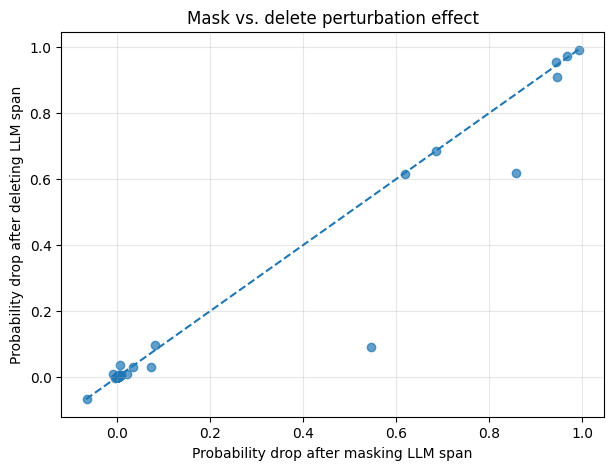

In [31]:
plot_df = result_df.dropna(subset=["prob_drop_masked", "prob_drop_delete"]).copy()

plt.figure(figsize=(7, 5))
plt.scatter(
    plot_df["prob_drop_masked"],
    plot_df["prob_drop_delete"],
    alpha=0.7
)

min_val = min(plot_df["prob_drop_masked"].min(), plot_df["prob_drop_delete"].min())
max_val = max(plot_df["prob_drop_masked"].max(), plot_df["prob_drop_delete"].max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Probability drop after masking LLM span")
plt.ylabel("Probability drop after deleting LLM span")
plt.title("Mask vs. delete perturbation effect")
plt.grid(True, alpha=0.3)
plt.show()

Points above the diagonal indicate that deleting the span causes a larger probability drop.
Points below the diagonal indicate that masking the span causes a larger probability drop.

/var/folders/9c/mdcbw50d74b4v7yjj79xw8yh0000gn/T/ipykernel_60081/463089990.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


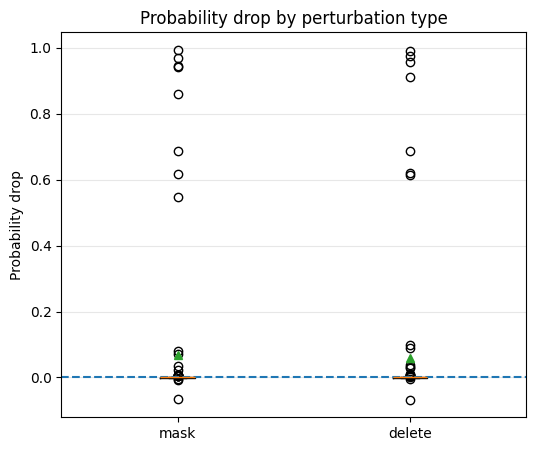

In [33]:
plt.figure(figsize=(6, 5))

plt.boxplot(
    [
        plot_df["prob_drop_masked"],
        plot_df["prob_drop_delete"]
    ],
    labels=["mask", "delete"],
    showmeans=True
)

plt.axhline(0, linestyle="--")
plt.ylabel("Probability drop")
plt.title("Probability drop by perturbation type")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

# Compare Inappropriate probabilities

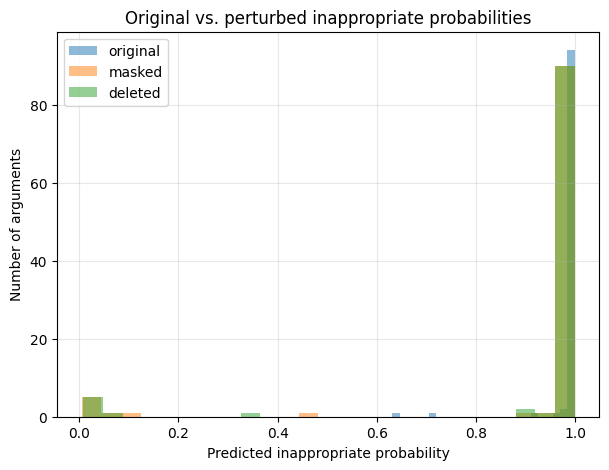

In [34]:
plt.figure(figsize=(7, 5))

plt.hist(
    plot_df["p_inappropriate_original"],
    bins=25,
    alpha=0.5,
    label="original"
)

plt.hist(
    plot_df["p_inappropriate_masked"],
    bins=25,
    alpha=0.5,
    label="masked"
)

plt.hist(
    plot_df["p_inappropriate_deleted"],
    bins=25,
    alpha=0.5,
    label="deleted"
)

plt.xlabel("Predicted inappropriate probability")
plt.ylabel("Number of arguments")
plt.title("Original vs. perturbed inappropriate probabilities")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

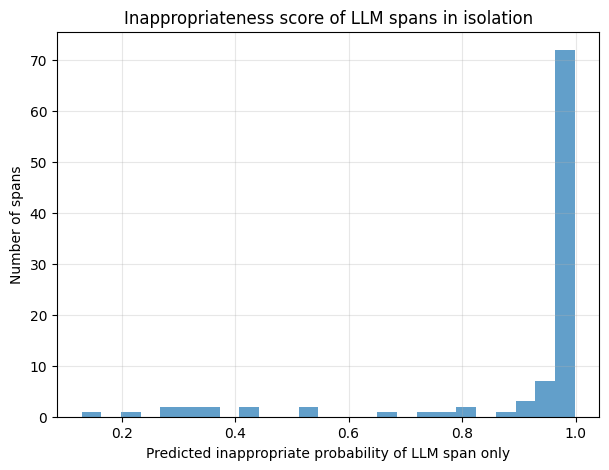

In [35]:
plt.figure(figsize=(7, 5))

plt.hist(
    plot_df["p_span_inappropriate"].dropna(),
    bins=25,
    alpha=0.7
)

plt.xlabel("Predicted inappropriate probability of LLM span only")
plt.ylabel("Number of spans")
plt.title("Inappropriateness score of LLM spans in isolation")
plt.grid(True, alpha=0.3)
plt.show()

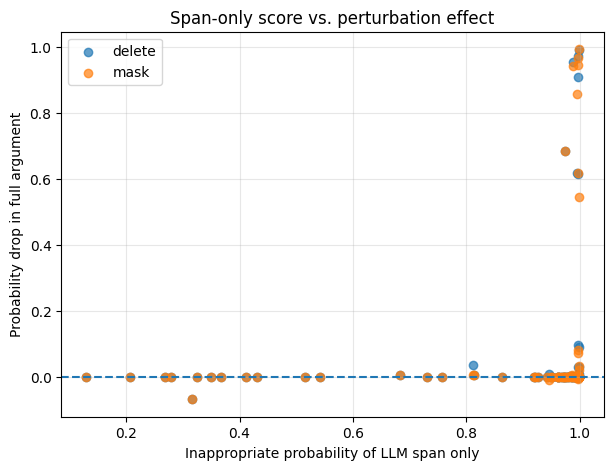

In [36]:
plt.figure(figsize=(7, 5))

plt.scatter(
    plot_df["p_span_inappropriate"],
    plot_df["prob_drop_delete"],
    alpha=0.7,
    label="delete"
)

plt.scatter(
    plot_df["p_span_inappropriate"],
    plot_df["prob_drop_masked"],
    alpha=0.7,
    label="mask"
)

plt.axhline(0, linestyle="--")

plt.xlabel("Inappropriate probability of LLM span only")
plt.ylabel("Probability drop in full argument")
plt.title("Span-only score vs. perturbation effect")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()